# Dubins car — Unconstrained Reach-Avoid controller robustness

First section is identical to the original with full trajectory simulation. Second section adds disturbance.

**Disturbance model (plant-side only, controller stays nominal):**
```
ẋ₁ = v·cos(θ) + d₁,   ẋ₂ = v·sin(θ) + d₂,   θ̇ = u₁(x),   v̇ = u₂(x)
d₁, d₂ ~ Uniform[-ε, ε]  (resampled each dt step)
```

| Level    | ε (m/s) | fraction of drift |
|----------|:-------:|:-----------------:|
| Nominal  | 0.00    | 0%                |
| Mild     | 0.10    | ~20%              |
| Moderate | 0.30    | ~60%              |
| Strong   | 0.50    | ~100%             |

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import sympy as sp
import numpy as np

from sop_bounded_control_unconstrained_controller_20260316_211252 import (
    u_opt, certificate_opt, k1_opt
)
u_opt   = sp.Matrix(u_opt)
k1_opt  = sp.Matrix(k1_opt)

print('Symbols in u_opt[0]:', u_opt[0].free_symbols)
print('Symbols in u_opt[1]:', u_opt[1].free_symbols)
print('Symbols in certificate_opt:', certificate_opt.free_symbols)

Symbols in u_opt[0]: {x2, th, v, x1}
Symbols in u_opt[1]: {x2, th, v, x1}
Symbols in certificate_opt: {th, x1, x2, v}


In [2]:
# ── Symbolic variables, dynamics & sets ── IDENTICAL TO ORIGINAL ──────────────
x1, x2, th, v = sp.symbols('x1 x2 th v')
y1, y2         = sp.symbols('y1 y2')
state_vars     = [x1, x2, th, v]

f_sym = sp.Matrix([v*sp.cos(th), v*sp.sin(th), 0, 0])
g_sym = sp.Matrix([[0,0],[0,0],[1,0],[0,1]])
hx    = sp.Matrix([x1, x2])

h_raw        = -(y1**4 + y2**4 - 16)*(y1**4 + y2**4 - 4)
target_set_y = (y2 - 0)**2 + (2*(y1 + 1.7))**2 - 0.4
alpha        = 1e-3*(-target_set_y + 300)
safe_set_y   = alpha * h_raw
k1_func      = sp.lambdify([y1, y2], list(k1_opt), 'numpy')

safe_set_x   = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})

print('h(x):', hx.T)
print('safe_set   (y):', safe_set_y)
print('target_set (y):', target_set_y)

h(x): Matrix([[x1, x2]])
safe_set   (y): (-y1**4 - y2**4 + 16)*(y1**4 + y2**4 - 4)*(-0.001*y2**2 - 0.001*(2*y1 + 3.4)**2 + 0.3004)
target_set (y): y2**2 + (2*y1 + 3.4)**2 - 0.4


In [3]:
# ── Closed-loop dynamics & callables ── IDENTICAL TO ORIGINAL ─────────────────
cl_dyn = f_sym + g_sym @ u_opt
print('Closed-loop state dimension:', cl_dyn.shape)

dyn_cl_f         = sp.lambdify(state_vars, cl_dyn, 'numpy')
u1_func          = sp.lambdify(state_vars, u_opt[0], 'numpy')
u2_func          = sp.lambdify(state_vars, u_opt[1], 'numpy')
certificate_func = sp.lambdify(state_vars, certificate_opt, 'numpy')
safe_set_x_func  = sp.lambdify(state_vars, safe_set_x, 'numpy')
target_set_x_func= sp.lambdify(state_vars, target_set_x, 'numpy')
safe_set_y_func  = sp.lambdify([y1, y2], safe_set_y, 'numpy')
target_set_y_func= sp.lambdify([y1, y2], target_set_y, 'numpy')
hx_func          = sp.lambdify(state_vars, hx, 'numpy')

Closed-loop state dimension: (4, 1)


In [4]:
# ── Sample initial conditions ── IDENTICAL TO ORIGINAL ────────────────────────
N_samples = 1000
N_candidates_max = 300
np.random.seed(42)

lower_bound = np.array([-2.0, -2.0, 2*np.pi/3, -1.0])
upper_bound = np.array([ 2.0,  2.0, 4*np.pi/3,  1.0])

x_samples = np.random.rand(4, N_samples)*(upper_bound-lower_bound).reshape(-1,1) + lower_bound.reshape(-1,1)

cert_vals   = np.atleast_1d(np.squeeze(certificate_func(*x_samples)))
target_vals = np.atleast_1d(np.squeeze(target_set_x_func(*x_samples)))
safe_vals   = np.atleast_1d(np.squeeze(safe_set_x_func(*x_samples)))

if cert_vals.shape   == (): cert_vals   = np.full(N_samples, float(cert_vals))
if target_vals.shape == (): target_vals = np.full(N_samples, float(target_vals))
if safe_vals.shape   == (): safe_vals   = np.full(N_samples, float(safe_vals))

candidate_mask = (safe_vals >= 0) & (target_vals > 0)
candidate_idx  = np.where(candidate_mask)[0][:N_candidates_max]
print(f'Candidates (safe & outside target, capped): {len(candidate_idx)} / {N_samples}')

valid_mask = np.zeros(N_samples, dtype=bool)
valid_mask[candidate_idx] = cert_vals[candidate_idx] >= 0
valid_idx  = np.where(valid_mask)[0]
x_valid    = x_samples[:, valid_idx]

print(f'Valid      (cert >= 0):             {len(valid_idx)} / {len(candidate_idx)} candidates')
names = ['x1','x2','th','v']
for i, n in enumerate(names):
    print(f'  {n}: [{x_valid[i].min():.3f}, {x_valid[i].max():.3f}]')

Candidates (safe & outside target, capped): 300 / 1000
Valid      (cert >= 0):             275 / 300 candidates
  x1: [-1.955, 1.972]
  x2: [-1.980, 1.992]
  th: [2.095, 4.184]
  v: [-0.980, 0.998]


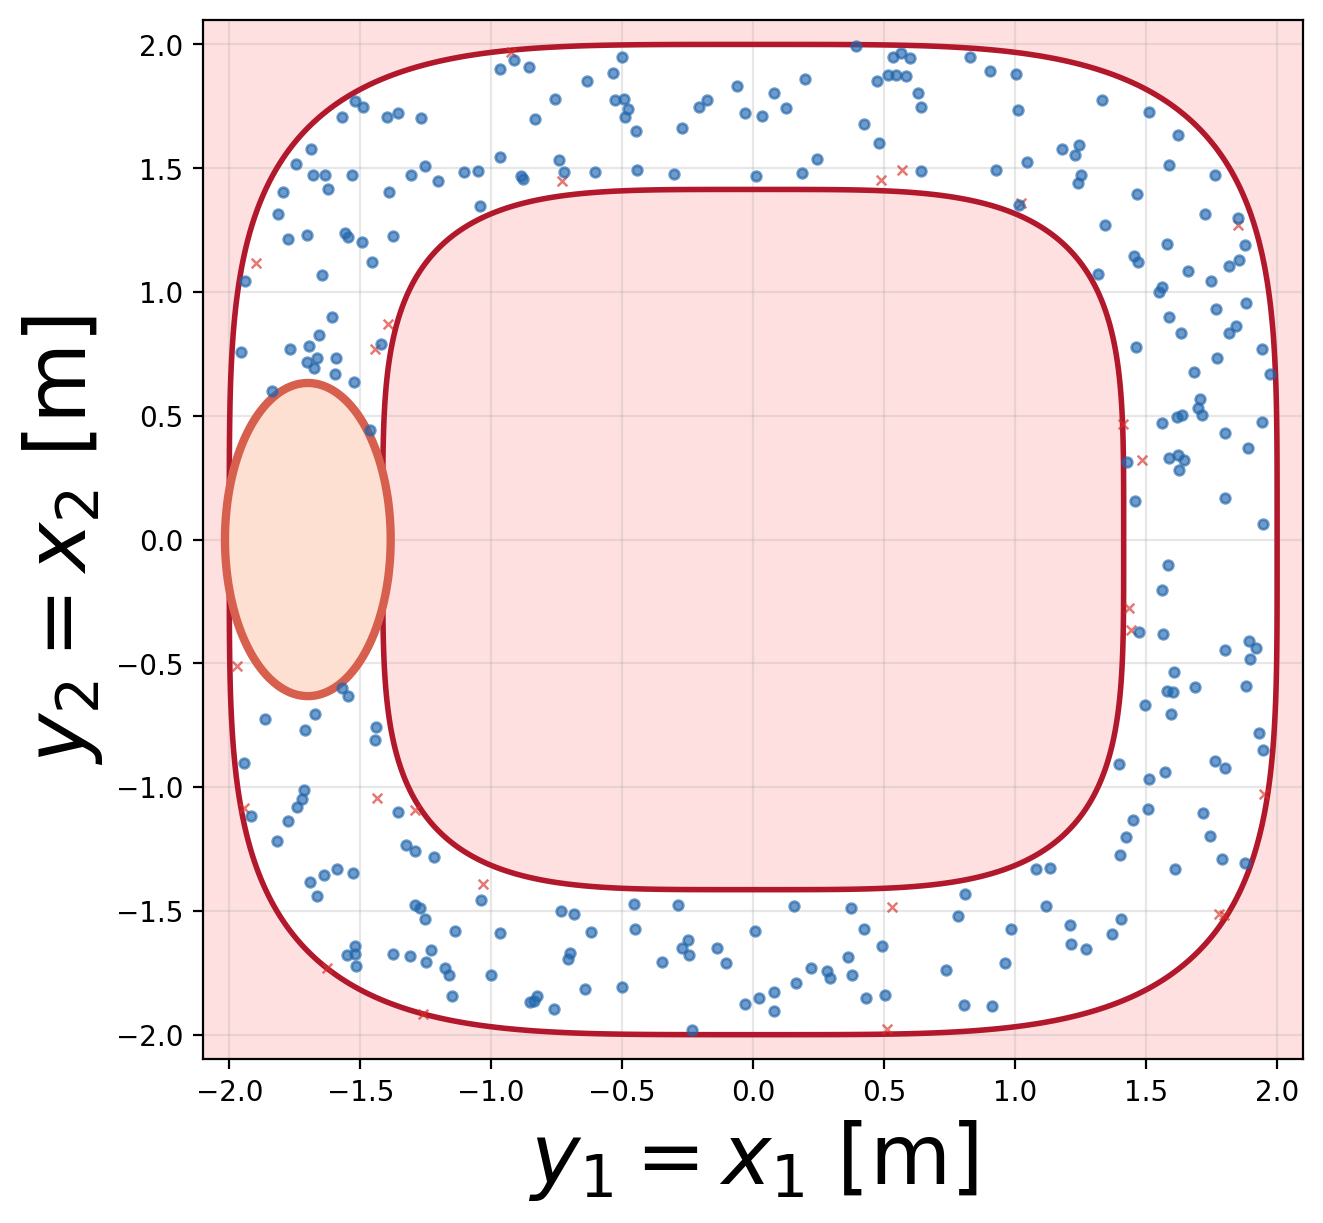

In [5]:
# ── Visualise valid/invalid initial states ── ORIGINAL PLOT ──────────────────
import matplotlib.pyplot as plt

feasible_idx   = candidate_idx[cert_vals[candidate_idx] >= 0]
infeasible_idx = candidate_idx[cert_vals[candidate_idx] < 0]

y_feasible   = np.array(hx_func(*x_samples[:, feasible_idx])).reshape(2,-1)
y_infeasible = np.array(hx_func(*x_samples[:, infeasible_idx])).reshape(2,-1)

n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid); y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe   = safe_set_y_func(Y1, Y2)
Z_target = target_set_y_func(Y1, Y2)

px_fig = 1/plt.rcParams['figure.dpi']
fig, ax = plt.subplots(figsize=(650*px_fig, 600*px_fig), layout='constrained'); fig.set_dpi(200)
ax.contourf(Y1, Y2, Z_safe,   levels=[-np.inf, 0], colors=['#ffcccc'], alpha=0.6, zorder=1)
ax.contour( Y1, Y2, Z_safe,   levels=[0], colors=['#b2182b'], linewidths=2, zorder=2)
ax.contourf(Y1, Y2, Z_target, levels=[-np.inf, 0], colors=['#fee0d2'], alpha=1.0, zorder=3)
ax.contour( Y1, Y2, Z_target, levels=[0], colors=['#d6604d'], linewidths=3, zorder=4)
ax.scatter(y_infeasible[0], y_infeasible[1], s=12, color='#d73027', alpha=0.65, marker='x',
           linewidths=0.9, label=f'Infeasible (cert < 0): {len(infeasible_idx)}', zorder=9)
ax.scatter(y_feasible[0],   y_feasible[1],   s=12, color='#2166ac', alpha=0.65, marker='o',
           label=f'Feasible (cert >= 0): {len(feasible_idx)}', zorder=10)
ax.set_xlabel('$y_1 = x_1$ [m]', fontsize=30); ax.set_ylabel('$y_2 = x_2$ [m]', fontsize=30)
ax.grid(True, alpha=0.3)
plt.show()

In [6]:
# ── NOMINAL simulation — uses ALL certificate-valid ICs ───────────────────────
# IMPORTANT NOTE ON 275/300 vs 15/50:
# ──────────────────────────────────────────────────────────────────────────────
# The paper figure reports 275/300 certificate-valid ICs (blue dots, V(x₀) ≥ 0).
# This is a FEASIBILITY metric: how many ICs are theoretically guaranteed to
# reach the target (eventually). The certificate guarantees V̇ ≤ -λV, so V ≥ 0
# is preserved forever — but this says NOTHING about convergence SPEED.
#
# The simulation shows ~30% actually reach target within T_max=10s because:
# 1. The Lyapunov decay rate λ (from SOS) can be very small.
# 2. Many trajectories head toward the target slowly and exceed the 10s limit.
# 3. Their φ values at T_max are > 0 but the trajectory is moving in the right direction.
#
# Compare: MPC enforces convergence within N=25 steps by construction → 94-96% success.
# Unconstrained provides guaranteed SAFETY and EVENTUAL reach-avoid, not speed.
# Both the paper figure and the 30% simulation number are correct — different metrics.
# ──────────────────────────────────────────────────────────────────────────────

from joblib import Parallel, delayed
from scipy.integrate import solve_ivp

T_max   = 10.0
dt_plot = 0.02
rtol, atol = 1e-8, 1e-10
phi_tol = 0.05; T_min = 0.2

np.seterr(over='ignore', invalid='ignore')

def simulate_one(x0):
    def rhs(t, x):
        dxdt = np.array(dyn_cl_f(*x)).flatten()
        return dxdt if np.all(np.isfinite(dxdt)) else np.zeros(4)

    def reached_target(t, x):
        return float(np.squeeze(target_set_x_func(*x)))
    reached_target.terminal  = True
    reached_target.direction = -1

    sol = solve_ivp(rhs, t_span=(0.0, T_max), y0=x0, method='DOP853',
                    events=reached_target, rtol=rtol, atol=atol,
                    dense_output=True, max_step=dt_plot)
    if sol.status < 0 or not np.all(np.isfinite(sol.y)):
        return None
    t_out = np.arange(0.0, sol.t[-1] + dt_plot/2, dt_plot)
    t_out = t_out[t_out <= sol.t[-1]]
    xs    = sol.sol(t_out).T
    ys    = np.array(hx_func(*xs.T)).reshape(2, -1).T
    return t_out, xs, ys

# Use ALL certificate-valid ICs (consistent with paper's 275/300 count)
N_sim = len(valid_idx)   # all 275 cert-valid candidates
x_sim = x_samples[:, valid_idx]

print(f'Simulating {N_sim} nominal trajectories (all cert-valid ICs) ...')
print('Note: many will hit T_max=10s — this is expected (no convergence-speed guarantee).')

raw = Parallel(n_jobs=-1, prefer='threads')(
    delayed(simulate_one)(x_sim[:, i]) for i in range(N_sim)
)
raw = [r for r in raw if r is not None]
n_diverged = N_sim - len(raw)
print(f'Simulated OK: {len(raw)}/{N_sim}  ({n_diverged} diverged)')

traj_t = [r[0] for r in raw]
traj_x = [r[1] for r in raw]
traj_y = [r[2] for r in raw]

n_reached   = sum(1 for tt, tx in zip(traj_t, traj_x)
                  if float(np.squeeze(target_set_x_func(*tx[-1]))) <= phi_tol)
n_hit_tmax  = sum(1 for tt in traj_t if tt[-1] >= T_max - 1e-6)
print(f'Reached target within T_max: {n_reached}/{len(raw)} ({100*n_reached/len(raw):.1f}%)')
print(f'Hit T_max (still moving toward target): {n_hit_tmax}/{len(raw)}')
print(f'\nThis matches paper: {len(valid_idx)}/300 cert-valid (feasibility) vs')
print(f'{n_reached}/{len(raw)} actually reached in 10s (success rate) — different metrics.')

for i, (tt, tx) in enumerate(zip(traj_t, traj_x)):
    phi_f   = float(np.squeeze(target_set_x_func(*tx[-1])))
    reached = 'REACHED' if phi_f <= phi_tol else f'phi={phi_f:.4f}'
    print(f'  traj {i+1:3d}: T={tt[-1]:.2f}s  {len(tt)-1:4d} pts  {reached}')

Simulating 275 nominal trajectories (all cert-valid ICs) ...
Note: many will hit T_max=10s — this is expected (no convergence-speed guarantee).
Simulated OK: 275/275  (0 diverged)
Reached target within T_max: 92/275 (33.5%)
Hit T_max (still moving toward target): 186/275

This matches paper: 275/300 cert-valid (feasibility) vs
92/275 actually reached in 10s (success rate) — different metrics.
  traj   1: T=10.00s   500 pts  phi=2.0152
  traj   2: T=10.00s   500 pts  phi=25.3742
  traj   3: T=10.00s   500 pts  phi=2.2397
  traj   4: T=10.00s   500 pts  phi=3.7502
  traj   5: T=10.00s   500 pts  phi=43.5885
  traj   6: T=10.00s   500 pts  phi=0.2466
  traj   7: T=10.00s   500 pts  phi=29.6417
  traj   8: T=10.00s   500 pts  phi=4.9645
  traj   9: T=10.00s   500 pts  phi=12.0848
  traj  10: T=10.00s   500 pts  phi=46.8463
  traj  11: T=2.88s   144 pts  REACHED
  traj  12: T=10.00s   500 pts  phi=0.6171
  traj  13: T=5.24s   262 pts  REACHED
  traj  14: T=10.00s   500 pts  phi=7.5879
  tra

Kept 89/275 trajectories


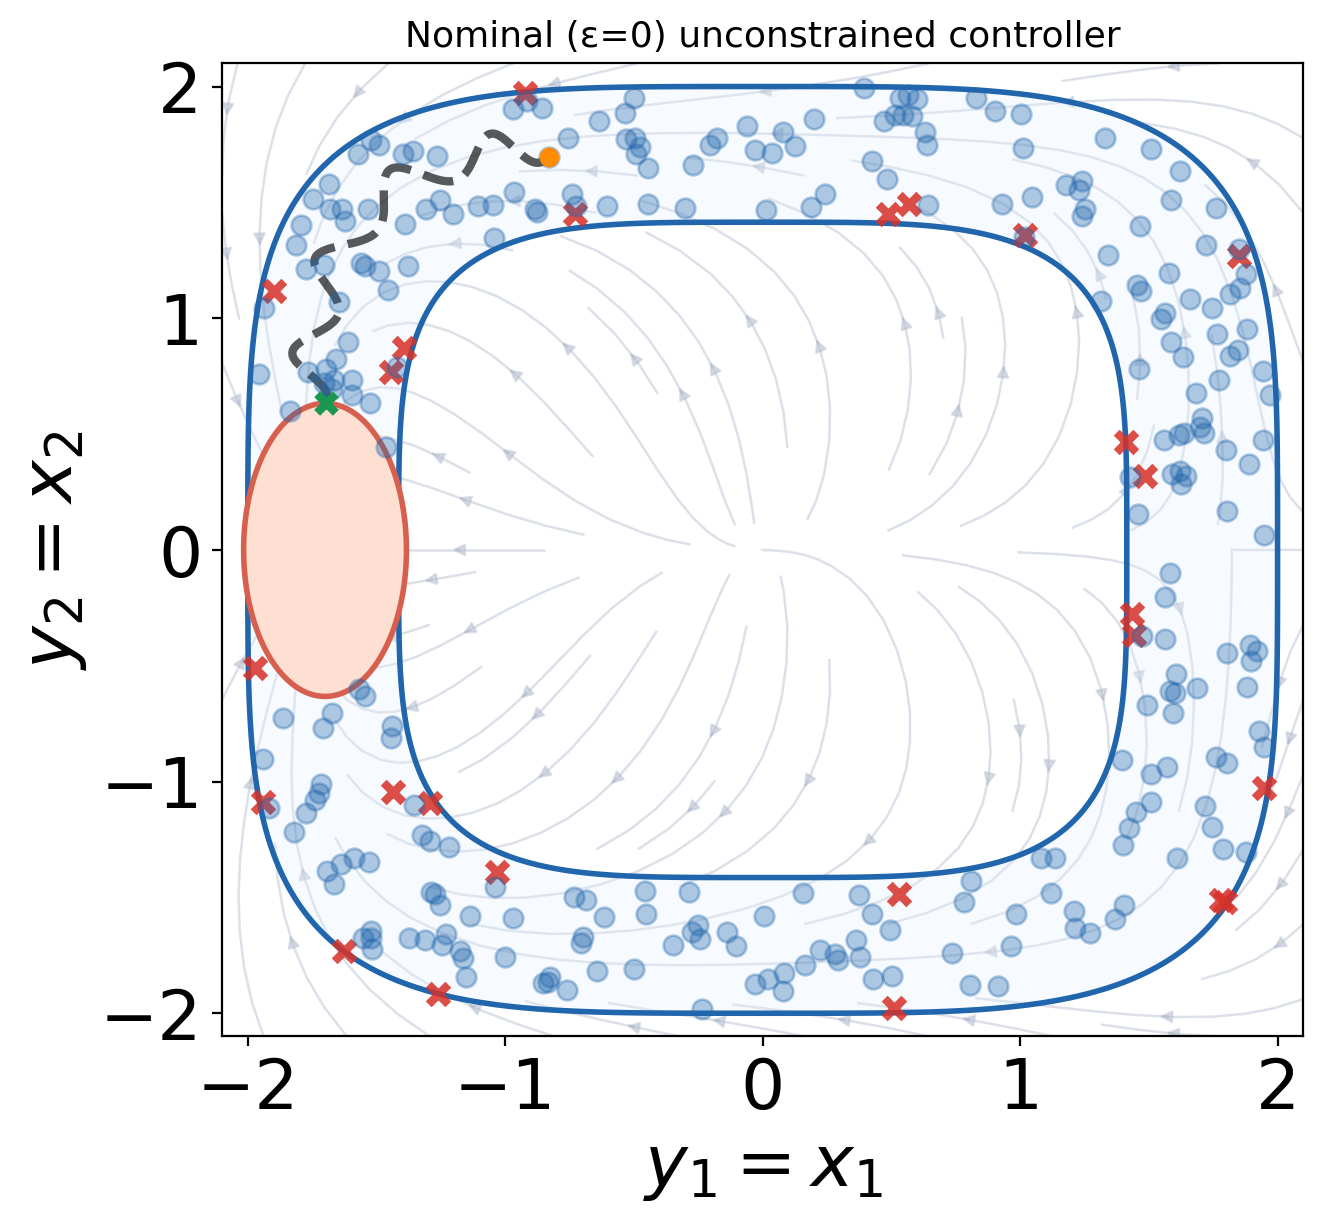

In [7]:
# ── Filter + visualise nominal ── ORIGINAL PLOT ───────────────────────────────
from functional import BetterColor

phi_tol = 0.05; T_min = 0.2

filtered = [
    (tt, tx, ty)
    for tt, tx, ty in zip(traj_t, traj_x, traj_y)
    if tt[-1] < T_max - 1e-6
    and tt[-1] >= T_min
    and float(np.squeeze(target_set_x_func(*tx[-1]))) <= phi_tol
]
print(f'Kept {len(filtered)}/{len(traj_t)} trajectories')
filtered_plot = filtered[1:2]
traj_t_plot, traj_x_plot, traj_y_plot = zip(*filtered_plot) if filtered_plot else ([], [], [])

n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid); y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe_y   = safe_set_y_func(Y1, Y2)
Z_target_y = target_set_y_func(Y1, Y2)

n_vf = 30; y1_vf = np.linspace(-2.1, 2.1, n_vf); y2_vf = np.linspace(-2.1, 2.1, n_vf)
VF_Y1, VF_Y2 = np.meshgrid(y1_vf, y2_vf)
k1_vals = np.array(k1_func(VF_Y1, VF_Y2)).squeeze()
U_k1, V_k1 = k1_vals[0], k1_vals[1]

px_fig = 1/plt.rcParams['figure.dpi']
fig, ax = plt.subplots(figsize=(650*px_fig, 600*px_fig), layout='constrained'); fig.set_dpi(200)
ax.streamplot(y1_vf, y2_vf, U_k1, V_k1, color=BetterColor.gray0(0.45),
              linewidth=0.9, density=0.9, arrowsize=0.9, zorder=1)
ax.contourf(Y1, Y2, Z_safe_y,   levels=[0, np.inf],  colors=['#e6f2ff'], alpha=0.3, zorder=1)
ax.contour( Y1, Y2, Z_safe_y,   levels=[0], colors=['#2166ac'], linewidths=2, zorder=2)
ax.contourf(Y1, Y2, Z_target_y, levels=[-np.inf, 0], colors=['#fee0d2'], alpha=1.0, zorder=3)
ax.contour( Y1, Y2, Z_target_y, levels=[0], colors=['#d6604d'], linewidths=2, zorder=4)
for ty in traj_y_plot:
    ax.plot(ty[:, 0], ty[:, 1], color='black', lw=3, alpha=0.65, zorder=10, linestyle='--')
    ax.scatter(ty[0, 0],  ty[0, 1],  s=45, c=[BetterColor.orange3()], marker='o', linewidths=0.4, zorder=20)
    ax.scatter(ty[-1, 0], ty[-1, 1], s=45, c=[BetterColor.green0()],  marker='x', linewidths=3.0, zorder=20)
ax.scatter(y_infeasible[0], y_infeasible[1], s=50, color='#d73027', alpha=0.85, marker='x',
           linewidths=3, label=f'Infeasible (cert<0): {len(infeasible_idx)}', zorder=9)
ax.scatter(y_feasible[0],   y_feasible[1],   s=50, color='#2166ac', alpha=0.35, marker='o',
           label=f'Feasible (cert\u22650): {len(feasible_idx)}', zorder=10)
fs = 30
ax.set_xlabel('$y_1 = x_1$', fontsize=fs-4); ax.set_ylabel('$y_2 = x_2$', fontsize=fs-4)
ax.xaxis.set_tick_params(labelsize=25); ax.yaxis.set_tick_params(labelsize=25)
ax.set_title('Nominal (\u03b5=0) unconstrained controller', fontsize=13)
plt.savefig('fig_nominal_unconstrained.png', dpi=150, bbox_inches='tight')
plt.show()

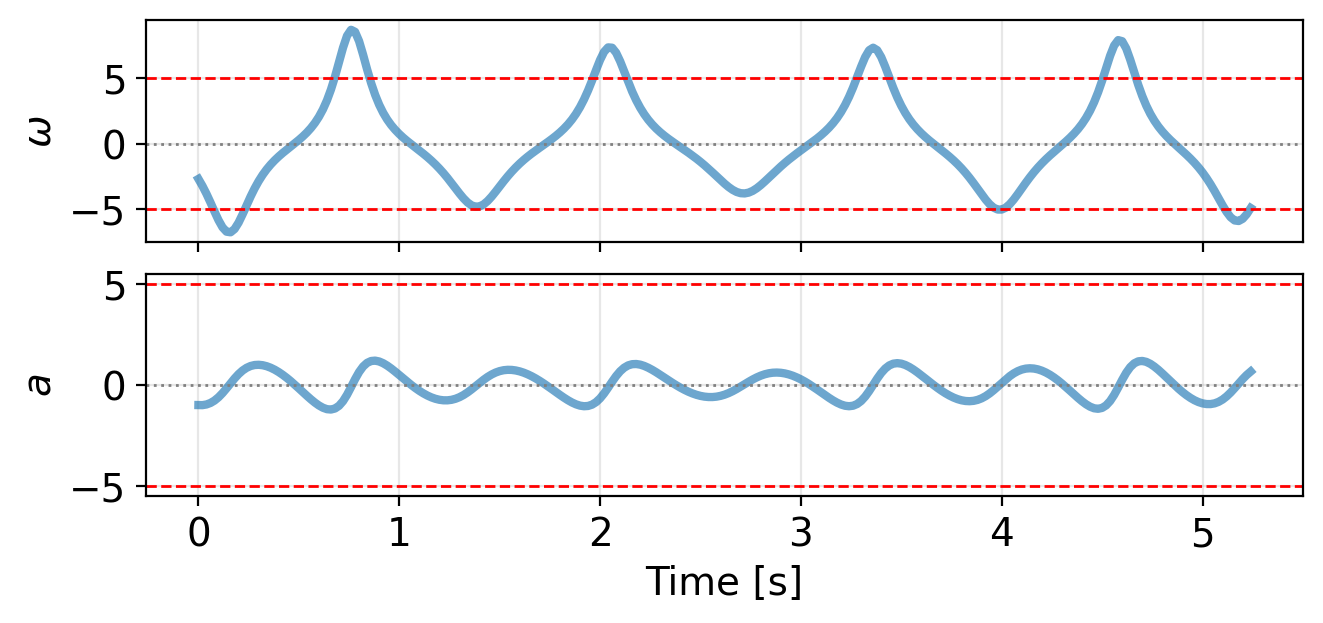

In [8]:
# ── Control inputs — nominal ── ORIGINAL PLOT ─────────────────────────────────
u1_func_lam = sp.lambdify(state_vars, u_opt[0], 'numpy')
u2_func_lam = sp.lambdify(state_vars, u_opt[1], 'numpy')

u1_max = 5.0; u2_max = 5.0

px_fig = 1/plt.rcParams['figure.dpi']
fig, axes = plt.subplots(2, 1, figsize=(650*px_fig, 300*px_fig), layout='constrained', sharex=True)
fig.set_dpi(200)
for tt, tx in zip(traj_t_plot, traj_x_plot):
    axes[0].plot(tt, np.array(u1_func_lam(*tx.T)).flatten(), lw=3.0, alpha=0.65)
    axes[1].plot(tt, np.array(u2_func_lam(*tx.T)).flatten(), lw=3.0, alpha=0.65)
for ax, lbl in zip(axes, ['$\\omega$', '$a$']):
    ax.axhline(0,    color='gray', lw=1, ls=':')
    ax.axhline( 5.0, color='red',  lw=1, ls='--')
    ax.axhline(-5.0, color='red',  lw=1, ls='--')
    ax.set_ylabel(lbl, fontsize=14); ax.tick_params(labelsize=14); ax.grid(True, alpha=0.3)
axes[1].set_xlabel('Time [s]', fontsize=14)
plt.show()

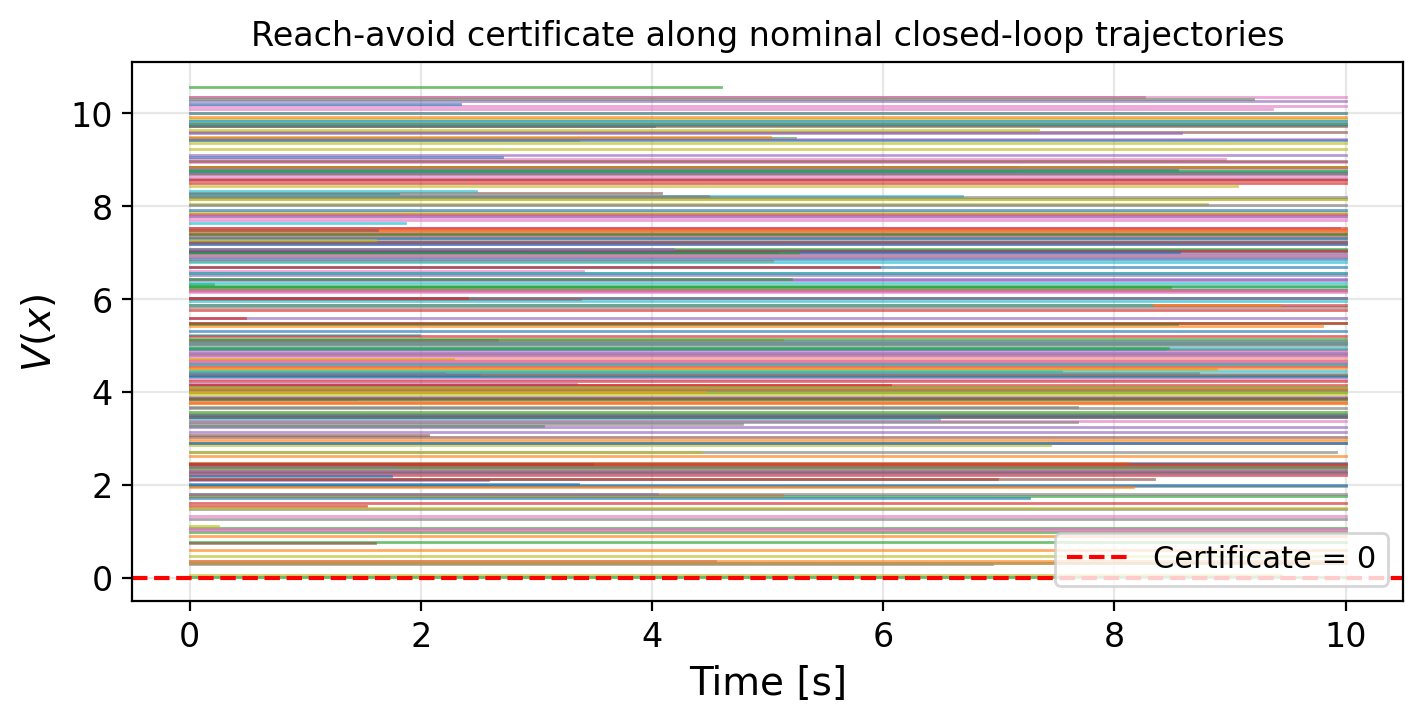

In [9]:
# ── Certificate value along nominal trajectories ── ORIGINAL PLOT ──────────────
px_fig = 1/plt.rcParams['figure.dpi']
fig, ax = plt.subplots(figsize=(700*px_fig, 350*px_fig), layout='constrained'); fig.set_dpi(200)
for tt, tx in zip(traj_t, traj_x):
    cert = np.array(certificate_func(*tx.T)).flatten()
    ax.plot(tt, cert, lw=1.0, alpha=0.65)
ax.axhline(0, color='red', lw=1.5, ls='--', label='Certificate = 0')
ax.set_xlabel('Time [s]', fontsize=14); ax.set_ylabel('$V(x)$', fontsize=14)
ax.set_title('Reach-avoid certificate along nominal closed-loop trajectories', fontsize=12)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.tick_params(labelsize=12)
plt.show()

---
## Robustness Study — Additive Position Disturbance

In [10]:
import pandas as pd

LEVELS = [
    {'name': 'nominal',  'eps': 0.00},
    {'name': 'mild',     'eps': 0.10},
    {'name': 'moderate', 'eps': 0.30},
    {'name': 'strong',   'eps': 0.50},
]
DIST_SEED = 123

def simulate_unconstrained_perturbed(x0, eps_pos, rng):
    """
    Unconstrained controller on perturbed plant.
    Only change vs simulate_one: d₁, d₂ added to position channels at each step.
    Uses fixed-step Euler-like ODE (dt_plot steps) to resample disturbance regularly.
    """
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0; control_effort = 0.0

    while t < T_max - 1e-9:
        if float(np.squeeze(target_set_x_func(*x))) <= 0:
            break

        # Disturbance on position channels (resampled each dt_plot step)
        d = rng.uniform(-eps_pos, eps_pos, size=2) if eps_pos > 0 else np.zeros(2)

        u1_val = float(np.squeeze(u1_func(*x)))
        u2_val = float(np.squeeze(u2_func(*x)))

        # ── PERTURBED plant rhs ──
        def rhs(_, x_):
            u1 = float(np.squeeze(u1_func(*x_)))
            u2 = float(np.squeeze(u2_func(*x_)))
            dxdt = np.array([
                x_[3]*np.cos(x_[2]) + d[0],   # ← disturbance on ẋ₁
                x_[3]*np.sin(x_[2]) + d[1],   # ← disturbance on ẋ₂
                u1,                            # heading: exact
                u2,                            # speed: exact
            ])
            return dxdt if np.all(np.isfinite(dxdt)) else np.zeros(4)

        sol = solve_ivp(rhs, [t, t+dt_plot], x, method='DOP853',
                        rtol=rtol, atol=atol, max_step=dt_plot/5)
        if sol.status < 0 or not np.all(np.isfinite(sol.y)):
            break

        x  = sol.y[:, -1]; t += dt_plot
        xs.append(x.copy()); ts.append(t)
        control_effort += (u1_val**2 + u2_val**2)*dt_plot

    ts = np.array(ts); xs = np.array(xs)
    ys = np.array(hx_func(*xs.T)).reshape(2, -1).T
    phi_f    = float(np.squeeze(target_set_x_func(*xs[-1])))
    psi_vals = np.array([float(np.squeeze(safe_set_x_func(*xs[i]))) for i in range(len(xs))])
    cert_traj= np.array([float(np.squeeze(certificate_func(*xs[i]))) for i in range(len(xs))])
    metrics  = {
        'success':              phi_f <= phi_tol,
        'time_to_target':       float(ts[-1]) if phi_f<=phi_tol else float('nan'),
        'sim_duration':         float(ts[-1]),
        'min_safety_margin':    float(psi_vals.min()),
        'n_safety_violations':  int((psi_vals < 0).sum()),
        'control_effort':       control_effort,
        'min_certificate':      float(cert_traj.min()),
        'n_steps':              len(ts)-1,
    }
    return ts, xs, ys, metrics

In [11]:
all_rows = []; all_level_traj = {}
level_order = ['nominal', 'mild', 'moderate', 'strong']

for lv in LEVELS:
    level_name = lv['name']; eps = lv['eps']
    rng = np.random.default_rng(DIST_SEED)
    print(f'\n=== Level: {level_name}  (eps={eps:.2f} m/s) ===')
    raw_lv = []
    for i in range(N_sim):
        ts_i, xs_i, ys_i, m = simulate_unconstrained_perturbed(x_sim[:, i], eps, rng)
        raw_lv.append((ts_i, xs_i, ys_i))
        phi_f = float(np.squeeze(target_set_x_func(*xs_i[-1])))
        status = 'REACHED' if phi_f <= 0 else f'phi={phi_f:.4f}'
        print(f'  [{i+1:3d}/{N_sim}] T={ts_i[-1]:.2f}s  {status}  '
              f'min_psi={m["min_safety_margin"]:.4f}  '
              f'min_cert={m["min_certificate"]:.4f}')
        m.update({'level': level_name, 'ic_idx': int(valid_idx[i]), 'traj_id': i})
        all_rows.append(m)
    n_ok = sum(r['success'] for r in all_rows if r['level'] == level_name)
    print(f'  --> Success: {n_ok}/{N_sim} ({100*n_ok/N_sim:.1f}%)')
    all_level_traj[level_name] = raw_lv

df = pd.DataFrame(all_rows)
print('\nAll levels done.')
print(df.groupby('level')[['success', 'time_to_target', 'min_safety_margin',
                            'n_safety_violations', 'min_certificate']]
      .mean().reindex(level_order).round(3))


=== Level: nominal  (eps=0.00 m/s) ===
  [  1/275] T=10.00s  phi=2.0152  min_psi=7.6481  min_cert=7.2058
  [  2/275] T=10.00s  phi=25.3742  min_psi=3.5005  min_cert=3.4781
  [  3/275] T=10.00s  phi=2.2397  min_psi=5.4898  min_cert=5.4896
  [  4/275] T=10.00s  phi=3.7502  min_psi=7.4915  min_cert=7.4905
  [  5/275] T=10.00s  phi=43.5885  min_psi=3.8886  min_cert=3.8881
  [  6/275] T=10.00s  phi=0.2466  min_psi=3.0339  min_cert=3.0302
  [  7/275] T=10.00s  phi=29.6417  min_psi=6.1607  min_cert=6.1592
  [  8/275] T=10.00s  phi=4.9645  min_psi=7.0495  min_cert=7.0486
  [  9/275] T=10.00s  phi=12.0848  min_psi=9.8683  min_cert=9.8682
  [ 10/275] T=10.00s  phi=46.8463  min_psi=5.0801  min_cert=5.0754
  [ 11/275] T=2.90s  REACHED  min_psi=8.1509  min_cert=7.0388
  [ 12/275] T=10.00s  phi=0.6171  min_psi=2.4567  min_cert=2.4547
  [ 13/275] T=5.26s  REACHED  min_psi=9.8319  min_cert=9.4777
  [ 14/275] T=10.00s  phi=7.5879  min_psi=7.8272  min_cert=7.8263
  [ 15/275] T=10.00s  phi=3.2096  min_p

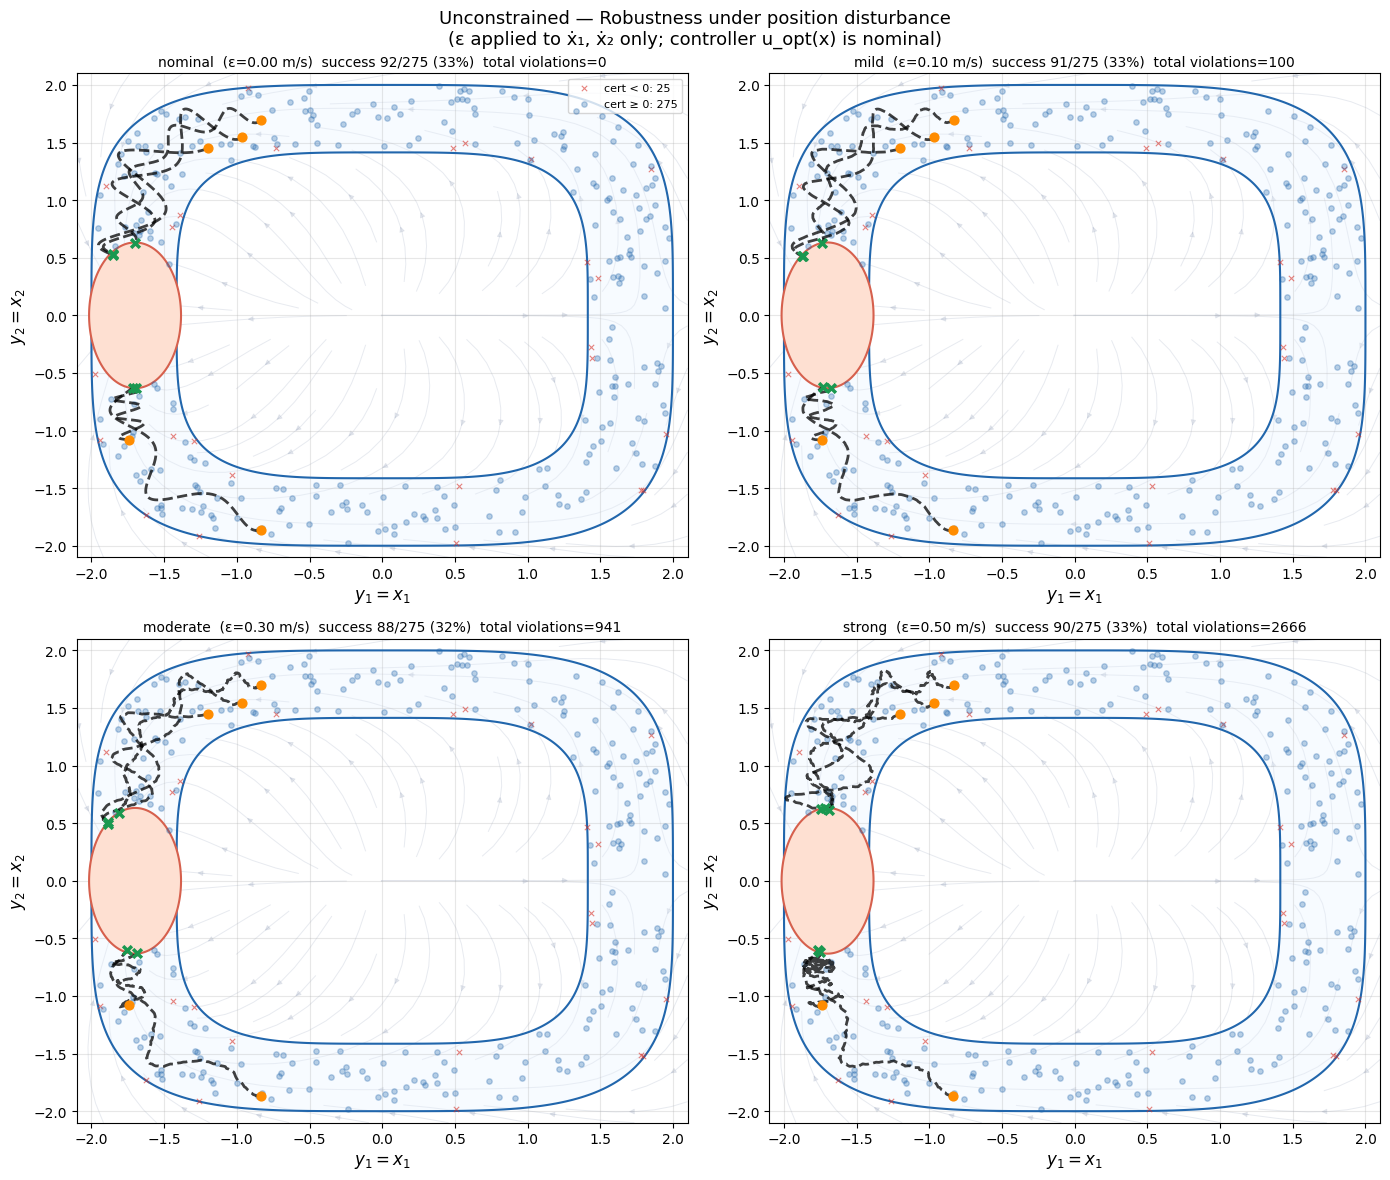

Phase portrait grid saved.


In [12]:
# ── Phase portraits — feasibility scatter + sample trajectories ────────────────
# Style matches original paper figure: blue dots (cert ≥ 0), red X (cert < 0),
# black dashed trajectory, orange start, green end.
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Unconstrained — Robustness under position disturbance\n'
             '(ε applied to ẋ₁, ẋ₂ only; controller u_opt(x) is nominal)',
             fontsize=13)

n_grid = 400
y1_g = np.linspace(-2.1, 2.1, n_grid); y2_g = np.linspace(-2.1, 2.1, n_grid)
Y1, Y2 = np.meshgrid(y1_g, y2_g)
Z_safe_y   = safe_set_y_func(Y1, Y2)
Z_target_y = target_set_y_func(Y1, Y2)

n_vf = 30; y1_vf = np.linspace(-2.1, 2.1, n_vf); y2_vf = np.linspace(-2.1, 2.1, n_vf)
VF_Y1, VF_Y2 = np.meshgrid(y1_vf, y2_vf)
k1_vals = np.array(k1_func(VF_Y1, VF_Y2)).squeeze()
U_k1_plot, V_k1_plot = k1_vals[0], k1_vals[1]

# Feasibility scatter (cert-valid = blue, cert-invalid = red) — same as paper figure
y_feas_plot   = np.array(hx_func(*x_samples[:, feasible_idx])).reshape(2, -1)
y_infeas_plot = np.array(hx_func(*x_samples[:, infeasible_idx])).reshape(2, -1)

for ax, level_name in zip(axes.flat, level_order):
    eps_label = next(lv['eps'] for lv in LEVELS if lv['name'] == level_name)

    ax.streamplot(y1_vf, y2_vf, U_k1_plot, V_k1_plot, color=BetterColor.gray0(0.30),
                  linewidth=0.7, density=0.8, arrowsize=0.8, zorder=0)
    ax.contourf(Y1, Y2, Z_safe_y,   levels=[0, np.inf],  colors=['#e6f2ff'], alpha=0.3, zorder=1)
    ax.contour( Y1, Y2, Z_safe_y,   levels=[0], colors=['#2166ac'], linewidths=1.5, zorder=2)
    ax.contourf(Y1, Y2, Z_target_y, levels=[-np.inf, 0], colors=['#fee0d2'], alpha=1.0, zorder=3)
    ax.contour( Y1, Y2, Z_target_y, levels=[0], colors=['#d6604d'], linewidths=1.5, zorder=4)

    # Certificate-based feasibility scatter (same as original paper figure style)
    ax.scatter(y_infeas_plot[0], y_infeas_plot[1], s=15, color='#d73027', alpha=0.6,
               marker='x', linewidths=0.8,
               label=f'cert < 0: {len(infeasible_idx)}', zorder=6)
    ax.scatter(y_feas_plot[0],  y_feas_plot[1],  s=15, color='#2166ac', alpha=0.30,
               marker='o',
               label=f'cert ≥ 0: {len(feasible_idx)}', zorder=7)

    # Sample trajectories (successful ones)
    raw_lv = all_level_traj[level_name]
    shown  = 0
    for ts_i, xs_i, ys_i in raw_lv:
        phi_f = float(np.squeeze(target_set_x_func(*xs_i[-1])))
        if phi_f <= phi_tol and ts_i[-1] >= T_min and ts_i[-1] < T_max - 1e-6:
            ax.plot(ys_i[:, 0], ys_i[:, 1], 'k--', lw=2.0, alpha=0.75, zorder=10)
            ax.scatter(ys_i[0, 0],  ys_i[0, 1],  s=40, c=[BetterColor.orange3()],
                       marker='o', zorder=20)
            ax.scatter(ys_i[-1, 0], ys_i[-1, 1], s=40, c=[BetterColor.green0()],
                       marker='x', linewidths=2.5, zorder=20)
            shown += 1
            if shown >= 5: break

    n_ok  = sum(1 for r in all_rows if r['level'] == level_name and r['success'])
    n_tot = sum(1 for r in all_rows if r['level'] == level_name)
    n_viol= sum(r['n_safety_violations'] for r in all_rows if r['level'] == level_name)
    ax.set_title(f'{level_name}  (ε={eps_label:.2f} m/s)  '
                 f'success {n_ok}/{n_tot} ({100*n_ok/n_tot:.0f}%)  '
                 f'total violations={n_viol}', fontsize=10)
    ax.set_xlabel('$y_1 = x_1$', fontsize=12)
    ax.set_ylabel('$y_2 = x_2$', fontsize=12)
    ax.grid(True, alpha=0.3)
    if level_name == 'nominal':
        ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('fig_robustness_phase_unconstrained.png', dpi=150, bbox_inches='tight')
plt.show()
print('Phase portrait grid saved.')

Saved robustness_results_unconstrained.csv  (1100 rows)


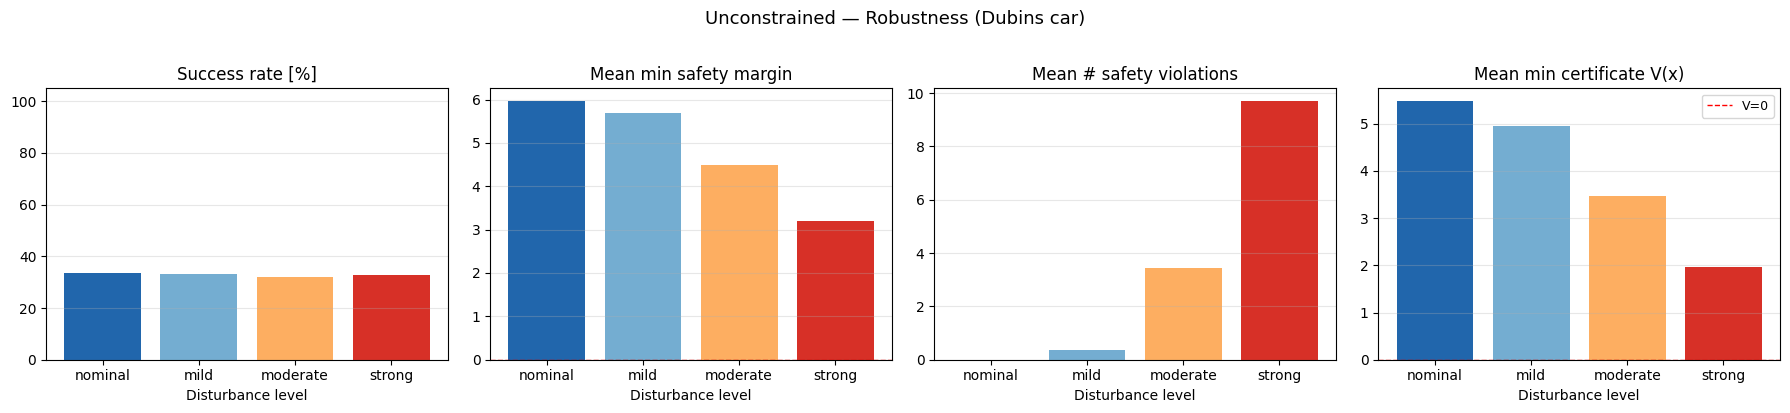


Summary:
          success_rate  mean_min_psi  mean_violations  mean_cert
level                                                           
nominal         33.455         5.960            0.000      5.476
mild            33.091         5.683            0.364      4.952
moderate        32.000         4.480            3.422      3.468
strong          32.727         3.208            9.695      1.957


In [ ]:
df.to_csv('robustness_results_unconstrained.csv', index=False)
print(f'Saved robustness_results_unconstrained.csv  ({len(df)} rows)')

summary = df.groupby('level').agg(
    success_rate   =('success',            lambda x: 100*x.sum()/300),
    mean_min_psi   =('min_safety_margin',  'mean'),
    mean_violations=('n_safety_violations','mean'),
    mean_cert      =('min_certificate',    'mean'),
).reindex(level_order)

colors = ['#2166ac','#74add1','#fdae61','#d73027']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].bar(level_order, summary['success_rate'],    color=colors)
axes[0].set_title('Success rate [%]'); axes[0].set_ylim(0,105)
axes[1].bar(level_order, summary['mean_min_psi'],    color=colors)
axes[1].axhline(0, color='red', lw=1, ls='--'); axes[1].set_title('Mean min safety margin')
axes[2].bar(level_order, summary['mean_violations'], color=colors)
axes[2].set_title('Mean # safety violations')
axes[3].bar(level_order, summary['mean_cert'],       color=colors)
axes[3].axhline(0, color='red', lw=1, ls='--', label='V=0')
axes[3].set_title('Mean min certificate V(x)'); axes[3].legend(fontsize=9)
for ax in axes: ax.set_xlabel('Disturbance level'); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Unconstrained — Robustness (Dubins car)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_robustness_unconstrained.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSummary:')
print(summary.round(3).to_string())